## UACN STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

uacn=pd.read_csv('../stock_data/uacn.csv') ## so it can be small letter. This is cool.
uacn=uacn.drop(columns=['high_price','low_price'])
uacn.rename(columns={'trade_date':'date'},inplace=True)
uacn['date']=pd.to_datetime(uacn['date'])
uacn['month']=uacn['date'].dt.month
uacn['quarter']=uacn['date'].dt.quarter
uacn['year']=uacn['date'].dt.year

uacn

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42786,UACN,2017-01-03,16.90,16.90,498301,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43346,UACN,2017-01-04,16.90,16.90,62573,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43456,UACN,2017-01-05,16.90,16.90,200411,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43566,UACN,2017-01-06,16.64,16.64,818027,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43656,UACN,2017-01-09,17.00,17.00,342510,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298144,UACN,2026-07-13,199.95,199.95,1592552,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298582,UACN,2026-07-14,199.95,199.95,657645,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299020,UACN,2026-07-15,199.95,199.95,237735,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299458,UACN,2026-07-16,199.95,199.95,1118997,2026-07-16T15:10:03.113936+00:00,7,3,2026


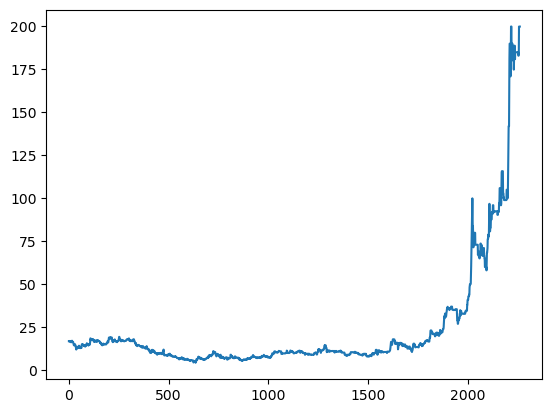

In [2]:
import matplotlib.pyplot as plt

plt.plot(uacn['close_price'])
plt.show()

In [3]:
uacn_end_month_df = (
    uacn
    .sort_values("date")
    .groupby(uacn["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

uacn_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45356,UACN,2017-01-31,16.50,16.50,784527,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47177,UACN,2017-02-28,13.65,13.65,864684,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49293,UACN,2017-03-31,13.00,13.00,127137,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51121,UACN,2017-04-28,14.47,14.47,203000,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53043,UACN,2017-05-31,14.99,14.99,495356,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35381,UACN,2026-03-31,99.00,99.00,274765,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281207,UACN,2026-04-30,181.50,181.50,3563686,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284273,UACN,2026-05-29,183.00,183.00,1562604,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294201,UACN,2026-06-30,185.00,185.00,678578,2026-06-30T15:10:03.08168+00:00,6,2,2026


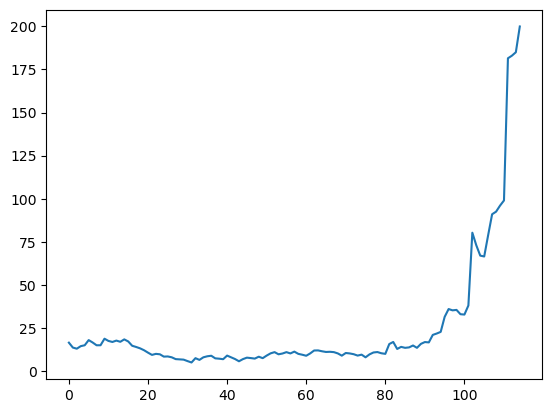

In [4]:
plt.plot(uacn_end_month_df['close_price'])
plt.show()

In [5]:
uacn_end_month_df['returns']=uacn_end_month_df['close_price'].pct_change()*100
uacn_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45356,UACN,2017-01-31,16.50,16.50,784527,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47177,UACN,2017-02-28,13.65,13.65,864684,2026-04-08T02:44:45.006295+00:00,2,1,2017,-17.272727
2,49293,UACN,2017-03-31,13.00,13.00,127137,2026-04-08T02:45:42.281198+00:00,3,1,2017,-4.761905
3,51121,UACN,2017-04-28,14.47,14.47,203000,2026-04-08T02:51:55.619599+00:00,4,2,2017,11.307692
4,53043,UACN,2017-05-31,14.99,14.99,495356,2026-04-08T02:52:57.421655+00:00,5,2,2017,3.593642
...,...,...,...,...,...,...,...,...,...,...,...
110,35381,UACN,2026-03-31,99.00,99.00,274765,2026-03-31T15:00:02.085058+00:00,3,1,2026,3.125000
111,281207,UACN,2026-04-30,181.50,181.50,3563686,2026-04-30T15:00:02.170664+00:00,4,2,2026,83.333333
112,284273,UACN,2026-05-29,183.00,183.00,1562604,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.826446
113,294201,UACN,2026-06-30,185.00,185.00,678578,2026-06-30T15:10:03.08168+00:00,6,2,2026,1.092896


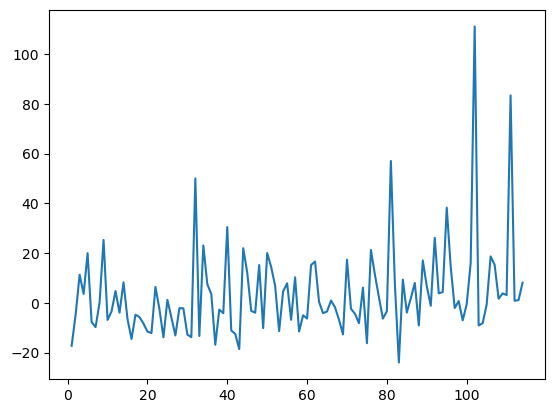

In [6]:
plt.plot(uacn_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(uacn_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-10.919864712267678, 1.0446450086998071e-19, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 878.2566306307922)
stationary


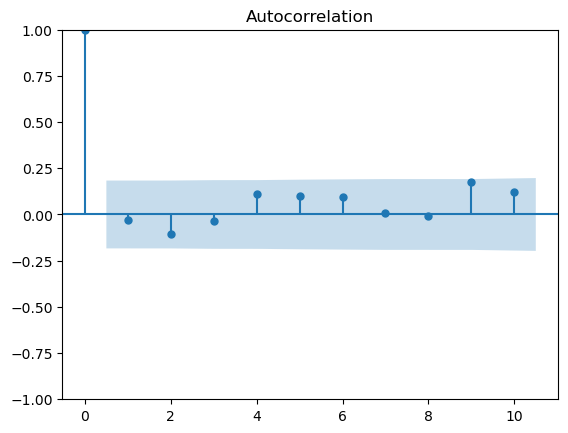

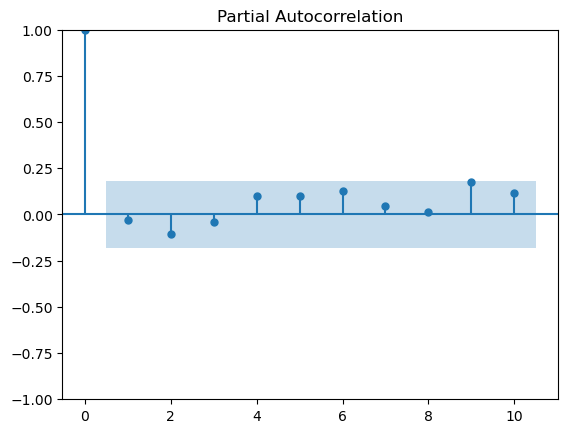

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(uacn_end_month_df['returns'].dropna(), lags=10)
plot_pacf(uacn_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=uacn_end_month_df['close_price'][:-10]
test=uacn_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -6.486734270778231]
[0, 0, 0, 0, 0, 1, -4.053832054898216]
[0, 0, 0, 0, 0, 2, -2.9657668010505054]
[0, 0, 0, 0, 1, 0, -3.006046241849213]
[0, 0, 0, 0, 1, 1, -2.179608236630485]
[0, 0, 0, 0, 1, 2, -1.7747264518524002]
[0, 0, 0, 0, 2, 0, -1.5199764189703062]
[0, 0, 0, 0, 2, 1, -1.2868173659105318]
[0, 0, 0, 0, 2, 2, -0.9623450641559435]
[0, 0, 0, 1, 0, 0, -3.2952115111070706]
[0, 0, 0, 1, 0, 1, -2.5411877250567563]
[0, 0, 0, 1, 0, 2, -2.503496452221]
[0, 0, 0, 1, 1, 0, -2.1271314196926077]
[0, 0, 0, 1, 1, 1, -1.9724645831726373]
[0, 0, 0, 1, 1, 2, -1.7792713501666886]
[0, 0, 0, 1, 2, 0, -1.2796568776911394]
[0, 0, 0, 1, 2, 1, -1.2795869838539988]
[0, 0, 0, 1, 2, 2, -1.311210190640709]
[0, 0, 0, 2, 0, 0, -2.7210282897481792]
[0, 0, 0, 2, 0, 1, -2.5240247920644925]
[0, 0, 0, 2, 0, 2, -2.487154473638375]
[0, 0, 0, 2, 1, 0, -1.97679670241095]
[0, 0, 0, 2, 1, 1, -1.9551828903838055]
[0, 0, 0, 2, 1, 2, -1.8893926739838554]
[0, 0, 0, 2, 2, 0, -1.309367959602742]
[0, 0, 0, 2, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-6.662409
0,0,0,0,0,0,0,-6.486734
27,0,0,1,0,0,0,-6.324347
54,0,0,2,0,0,0,-6.238665
177,0,2,0,1,2,0,-5.850819
...,...,...,...,...,...,...,...
652,2,2,0,0,1,1,0.670690
670,2,2,0,2,1,1,0.670768
661,2,2,0,1,1,1,0.670789
653,2,2,0,0,1,2,0.671109


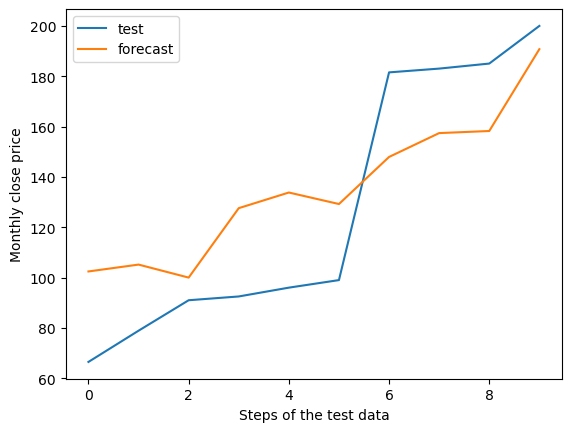

r2_score:  0.6711838879724017
rmse:  28.66891677318687
description:  count    115.000000
mean      24.615304
std       37.016137
min        5.000000
25%        9.000000
50%       11.300000
75%       17.100000
max      199.950000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=uacn_end_month_df['close_price'][:-10]
y_test=uacn_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', uacn_end_month_df.close_price.describe())

We will work with this.